<a href="https://colab.research.google.com/github/forbiddenscholar/ArtExtract/blob/main/ArtExtract_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ArtExtract (Model for Art classification)
**Mohit Deharkar** | Undergrad @ IIT Jodhpur

This notebook implements the pieces of work as demanded in the Task 1

Due to compute constraints, I preferred to proceed with a smaller dataset : [Wikiart-tiny](https://huggingface.co/datasets/yonigozlan/wikiart-tiny) from huggingface which is the subset of the original wikiart dataset

In [1]:
# importing the wikiart-tiny dataset
from datasets import load_dataset
dataset = load_dataset("yonigozlan/wikiart-tiny", split='train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/459M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [2]:
dataset

Dataset({
    features: ['image', 'artist', 'genre', 'style'],
    num_rows: 1000
})

In [3]:
dataset[0]['image'].size, dataset[1]['image'].size

((750, 597), (1382, 1659))

In [4]:
## we can see clearly that the resolution of every image is different
## so we will resize the dataset images to same resolution
IMAGE_SIZE = [224, 224]
from PIL import Image
def resize_images(examples):
  resized_images = [image.convert("RGB").resize(IMAGE_SIZE) for image in examples['image']]
  examples['image'] = resized_images
  return examples

## apply the transformation
dataset = dataset.map(resize_images, batched=True)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [5]:
# now check whether the images are resized
dataset[1]['image'].size

(224, 224)

# My approach :
1. Use CNN for classification
2. Use CRNN for classifcation
   - LSTM v/s
   - GRU
3. Compare results of all three architectures

### Data processing

In [6]:
import numpy as np

# now, sequentially mapping the class ids as zero indexed as the loss function demands

artist_classes = sorted(dataset.unique('artist'))
genre_classes = sorted(dataset.unique('genre'))
style_classes = sorted(dataset.unique('style'))

artist_classes_num = len(artist_classes)
genre_classes_num = len(genre_classes)
style_classes_num = len(style_classes)

artist_to_id = {v: i for i, v in enumerate(artist_classes)}
genre_to_id = {v: i for i, v in enumerate(genre_classes)}
style_to_id = {v: i for i, v in enumerate(style_classes)}

def preprocess_data(examples):

  # storing the artist ids in new lists :
  examples['artist_labels'] = np.array([int(artist_to_id[artist_id]) for artist_id in examples['artist']], dtype=np.int32)
  examples['genre_labels'] = np.array([int(genre_to_id[genre_id]) for genre_id in examples['genre']], dtype=np.int32)
  examples['style_labels'] = np.array([int(style_to_id[style_id]) for style_id in examples['style']], dtype=np.int32)

  return examples

In [7]:
# now we will apply the preprocess_data function
# also, we need to convert the processed data into tf.data.Dataset objects for efficient training

import tensorflow as tf

# process the complete data
full_data_processed = dataset.map(preprocess_data, batched=True)

# now split the data into train, val and test
full_data_processed = full_data_processed.train_test_split(test_size=0.2)
train_data = full_data_processed['train'] # 80%
test_data = full_data_processed['test']   # 20%
test_data = test_data.train_test_split(test_size=0.5)
val_data = test_data['train']             # 10%
test_data = test_data['test']             # 10%

def preprocess_tf(image, labels):
    image = tf.cast(image, tf.float32) / 255.0
    labels = (labels['artist_labels'], labels['genre_labels'], labels['style_labels'])
    return image, labels

# now covert it to tensorflow data
train_data_tf = train_data.to_tf_dataset(
    columns=["image"],
    label_cols=["artist_labels", "genre_labels", "style_labels"],
    shuffle=True, # shuffle for train
    batch_size=32
).map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

test_data_tf = test_data.to_tf_dataset(
    columns=["image"],
    label_cols=["artist_labels", "genre_labels", "style_labels"],
    shuffle=False,
    batch_size=32
).map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

val_data_tf = val_data.to_tf_dataset(
    columns=["image"],
    label_cols=["artist_labels", "genre_labels", "style_labels"],
    shuffle=False,
    batch_size=32
).map(preprocess_tf, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


## Starting with the CNN model
I considered the following CNN architectures :
- LeNet
- VGGnet
- ResNet
- AlexNet
- EfficientNet
- DenseNet

I chose to proceed with ResNet50 as :
- The skip connections allows the training of such deep models without performance degradation, this is a crucial advantage over shallow VGG, Alex and LeNet architectures
- The 50 deep layers are essential for differentiating subtle artistic classes, genre and artist in a diverse dataset like wikiart
- suitability for transfer learning, allows to load pretrained imagenet weights instead of training the complete model from scratch avoiding overfitting.

In [8]:
# First make a ResNet 50 model for image classification
# make the model architectutre, remove the classification layer and freeze trainable layers
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D

myResnet = ResNet50(weights='imagenet', input_shape=IMAGE_SIZE + [3], include_top=False) ## remove the fully connected classificaiton layer
for layer in myResnet.layers:
  layer.trainable = False

# make the flatten layer
flattenLayer = GlobalAveragePooling2D()(myResnet.output)

# make the classification heads

# 1. artist classification
artist_output = Dense(artist_classes_num, activation='softmax', name ='artist_output')(flattenLayer)

# 2. genre classification
genre_output = Dense(genre_classes_num, activation='softmax', name ='genre_output')(flattenLayer)

# 3. style classification
style_output = Dense(style_classes_num, activation='softmax', name ='style_output')(flattenLayer)

# create the multi-output model
model = Model(inputs=myResnet.input, outputs=[artist_output, genre_output, style_output])

print(model.summary())

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,690,162 (90.37 MB)

 Trainable params: 102,450 (400.20 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


## The Hyperparameters
### Activation function
While deciding which activation function to use, i had choices for :

- Sigmoid
- ReLU
- Softmax
- Swish
- TanH

I landed on going with softmax as it fits the best in multiclass classification as it gives the probabilities for each class in artist, genre and style category that sums up to 1.

Reference : [Activation functions for Multiclass Classification](https://medium.com/@heyamit10/activation-functions-for-multiclass-classification-8980d8c59707#2bd5)

### Optimizer
Choices I came upon :
- Adam
- SGD

Went with Adam. Even adam had its own disadvantage of converging at the very beginning of the training, in our case, we have freezed the maximum training layers of the resnet50 since we are using imagenet weights, so we only have the classification heads to be trained. So, here using adam is no harm and will work best

Reference : [Overview of optimizers for DNN](https://medium.com/@shengfang/overview-of-optimizers-for-dnn-when-and-how-to-choose-which-optimizer-part-2-16524dedbfd2)

### Loss Function
categorical_crossentropy is to be used but since, it requires labels in the form of one-hot encoded vectors and our dataset has it as integer IDs, it’s better to go with sparse_categorical_crossentropy

Reference : [Which loss function and metrics to use for multi-class classification](https://stackoverflow.com/questions/59336899/which-loss-function-and-metrics-to-use-for-multi-label-classification-with-very)


In [9]:
from tensorflow.keras.metrics import F1Score

metrics ={
    "artist_output": ["accuracy"],
    "genre_output": ["accuracy"],
    "style_output": ["accuracy"]
}

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss={
        'artist_output': 'sparse_categorical_crossentropy',
        'genre_output': 'sparse_categorical_crossentropy',
        'style_output': 'sparse_categorical_crossentropy'
    },
    metrics = metrics
)

print("Model compiled successfully!")

Model compiled successfully!


In [10]:
history = model.fit(
    train_data_tf,
    validation_data=val_data_tf,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 760ms/step - artist_output_accuracy: 0.0211 - artist_output_loss: 3.7174 - genre_output_accuracy: 0.2375 - genre_output_loss: 2.4130 - loss: 8.9020 - style_output_accuracy: 0.0988 - style_output_loss: 2.7715 - val_artist_output_accuracy: 0.0400 - val_artist_output_loss: 3.4339 - val_genre_output_accuracy: 0.1600 - val_genre_output_loss: 2.4403 - val_loss: 8.2023 - val_style_output_accuracy: 0.1100 - val_style_output_loss: 2.4622
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step - artist_output_accuracy: 0.0288 - artist_output_loss: 3.3559 - genre_output_accuracy: 0.2407 - genre_output_loss: 2.2649 - loss: 8.0515 - style_output_accuracy: 0.1707 - style_output_loss: 2.4308 - val_artist_output_accuracy: 0.0400 - val_artist_output_loss: 3.2585 - val_genre_output_accuracy: 0.1600 - val_genre_output_loss: 2.2827 - val_loss: 7.6837 - val_style_output_accuracy: 0.2200 - val_style_output_loss: 2.2544
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 260ms/step

In [11]:
results = model.evaluate(test_data_tf, return_dict=True)
for k, v in results.items():
    print(f"{k}: {v:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - artist_output_accuracy: 0.1204 - artist_output_loss: 3.0539 - genre_output_accuracy: 0.2674 - genre_output_loss: 2.0773 - loss: 7.3420 - style_output_accuracy: 0.3445 - style_output_loss: 2.2287
artist_output_accuracy: 0.0900
artist_output_loss: 3.0834
genre_output_accuracy: 0.2700
genre_output_loss: 2.0511
loss: 7.3813
style_output_accuracy: 0.3300
style_output_loss: 2.2918


Here, the results are very low than what is expected.

But considering that the dataset is very small (trained on only 800 images and validated and tested on 100, 100), the aim of this task is to get onto the CRNN model and study the difference it makes in the results which have been taken care of in the next cells :

## Classification Metrics
Relying on accuracy is not worth in multiclass classifications

Choices :
- Macro F1
- Balanced accuracy

Since our data is unbalanced, maro f1 is preferred

In [12]:
# calculating f1_scores
y_pred = model.predict(test_data_tf)
y_pred_classes = [np.argmax(pred, axis=1) for pred in y_pred]
y_true = [[], [], []]

for x, y in test_data_tf:
    for i in range(3):
        y_true[i].append(y[i])

y_true = [tf.concat(part, axis=0) for part in y_true]
y_true_np = [y.numpy() for y in y_true]

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


### F1 Score for CNN

In [13]:
from sklearn.metrics import f1_score
f1_scores = [
    f1_score(y_true_np[i], y_pred_classes[i], average='macro')
    for i in range(3)
]

overall_f1 = sum(f1_scores) / len(f1_scores)
print("Overall Macro F1 for CNN:", overall_f1)

Overall Macro F1: 0.03668732783313646


### Predicted Class Distribution for CNN model

In [14]:
for i in range(3):
    print(f"\nOutput {i+1}")
    print("True distribution:", np.bincount(y_true_np[i]))
    print("Pred distribution:", np.bincount(y_pred_classes[i]))


Output 1
True distribution: [ 1  4  5  4 10  3  1  3  3  0  1  3  3  4  9  2  7  7  5  3  5  3  8  6]
Pred distribution: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 42  0  0  0  0  0  0  0 58]

Output 2
True distribution: [ 9 14  2 27  2 20  6  4  4 12]
Pred distribution: [ 0  0  0 97  0  3]

Output 3
True distribution: [ 0  0  8  5  5  3  1 32  2  7  0 14 10  4  9]
Pred distribution: [ 0  0  0  0  0  0  0 95  0  0  0  0  5]


Here it is obseravable that the imbalance is much high in the predictions for a few classses

### Classification Report for CNN

In [17]:
from sklearn.metrics import classification_report

for i in range(3):
    print(f"\nOutput {i+1}")
    print(classification_report(y_true_np[i], y_pred_classes[i]))


Output 1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        10
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         4
          14       0.10      0.44      0.16         9
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         7
          17       0.00      0.00      0.00         7
          18     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

From here, we can infer that there is a severe class imbalance and the model predicts more dominant classes

### Confusion Matrix for CNN

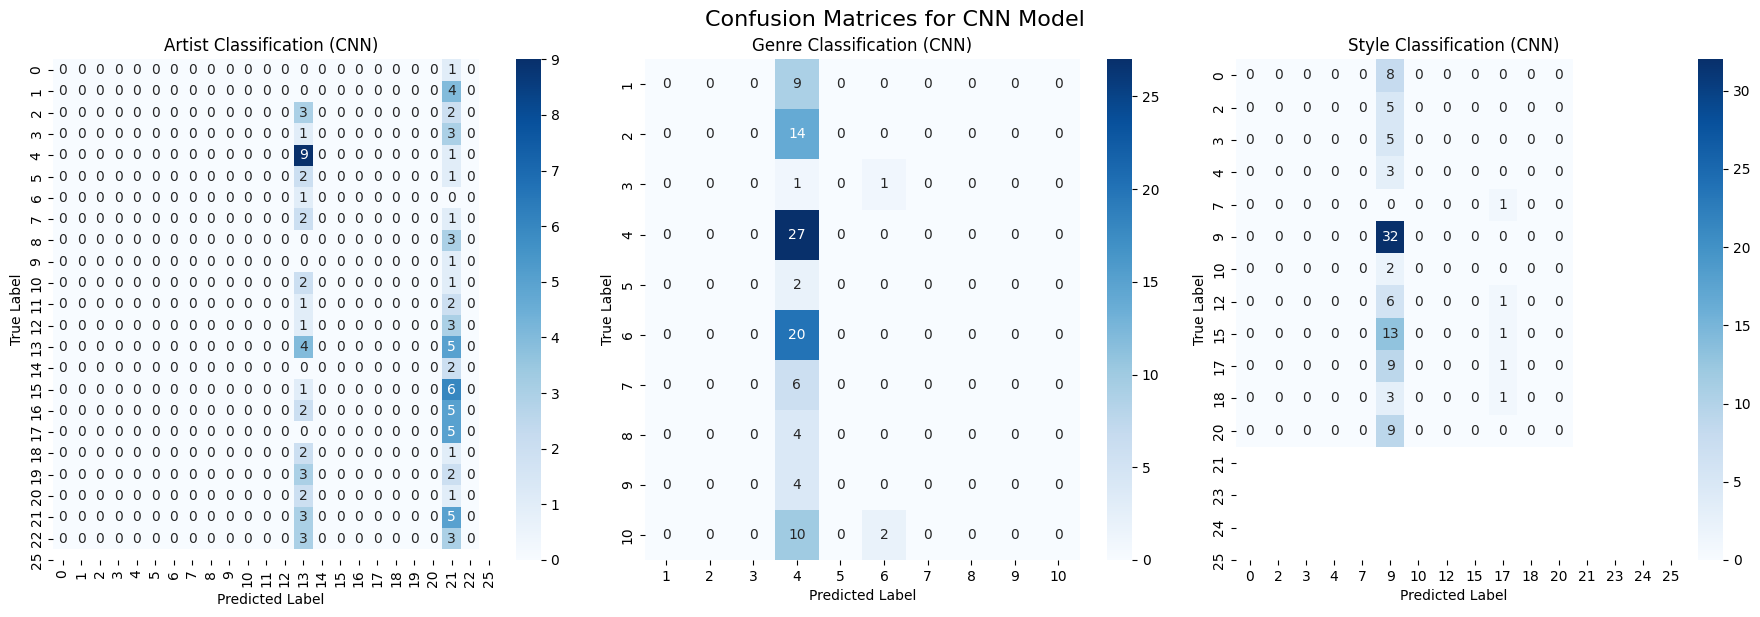

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_class_names = {
    'artist': artist_classes,
    'genre': genre_classes,
    'style': style_classes
}

output_titles = ['Artist Classification (CNN)', 'Genre Classification (CNN)', 'Style Classification (CNN)']

plt.figure(figsize=(18, 6))

for i in range(3):
    cm_cnn = confusion_matrix(y_true_np[i], y_pred_classes[i])

    current_class_names = all_class_names[['artist', 'genre', 'style'][i]]

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues',
                xticklabels=current_class_names, yticklabels=current_class_names)
    plt.title(output_titles[i])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.suptitle('Confusion Matrices for CNN Model', y=1.02, fontsize=16)
plt.show()

- metrics used : classification report, f1_score, class distributions, confusion matrix

- since the dataset size is too small (1000 images) which is not enough for transfer learning, we get a very low f1_score and a biased output for a few classes

-  f1_score emerged out to be the best evaluation metric here because accuracy was giving better results (which is not true and we can't rely on that only)

-  to fix this issues slightly, i tried lowering the learning rate of optimization function and the f1_score rised by 0.01

-  to address the class imbalance issue, assigning higher weights to minority classes in the loss fucntion can be done

- data augmentation can also be done to increase the size of dataset

### Outlier detection for CNN

Total misclassified samples for Artist (CNN): 91


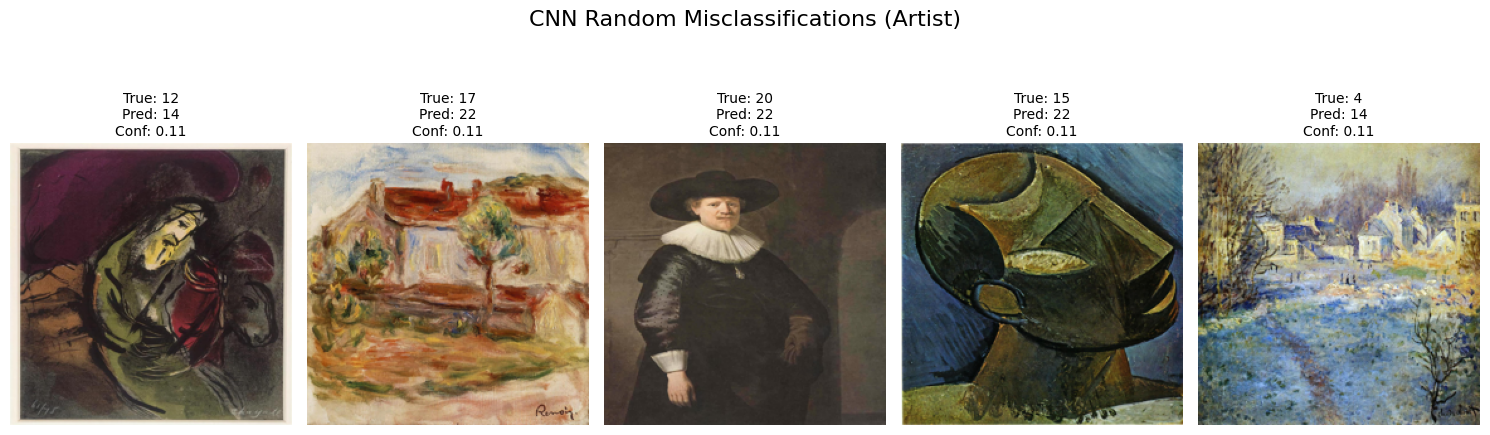

In [19]:
import numpy as np
import matplotlib.pyplot as plt

all_images = []
all_labels = []
for images_batch, labels_batch in test_data_tf:
    all_images.append(images_batch.numpy())
    all_labels.append(labels_batch[0].numpy())
all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

artist_preds_probs = model.predict(test_data_tf, verbose=0)[0]


misclassified_indices_cnn = np.where(y_true_np[0] != y_pred_classes[0])[0]

print(f"Total misclassified samples for Artist (CNN): {len(misclassified_indices_cnn)}")

num_to_display = min(5, len(misclassified_indices_cnn))

if num_to_display > 0:
    np.random.shuffle(misclassified_indices_cnn)
    display_indices = misclassified_indices_cnn[:num_to_display]

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(display_indices):
        true_label = y_true_np[0][idx]
        predicted_label = y_pred_classes[0][idx]
        confidence = artist_preds_probs[idx, predicted_label]

        plt.subplot(1, num_to_display, i + 1)
        plt.imshow(all_images[idx])
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", fontsize=10)
    plt.tight_layout()
    plt.suptitle('CNN Random Misclassifications (Artist)', y=1.05, fontsize=16)
    plt.show()
else:
    print("No misclassified samples found to display for CNN.")

The above images show where the model made an incorrect classification for the given artist.

The displayed confidence reflects the probability assigned to the model's (incorrect) predicted class.

### Analysis of CNN Model :

After training, a deeper analysis using F1-scores, class distribution, and classification report was performed

**Conclusion for CNN:** The CNN model, despite using transfer learning, struggled significantly due to the small dataset size and severe class imbalance, leading to a biased and poor performance in feature learning for diverse categories.

# Now, moving towards defining the CRNN architecture

## CRNN Model : Combining CNN with Recurrent Layers
I continued to use the ResNet50 CNN backbone from above for the CRNN architecture for feature extraction.

While finding the optimum RNN model for this task, i found out that LSTM and GRU would be the best.

Moreover, GRU trains faster and is more effective on small datasets (as such in this case)

So, I experimented with both models
- CRNN using LSTM
- CRNN using GRU

The width dimension of the CNN was treated as timesteps and the height and channel dimensions were flattened into features. Now, this 3D vector (converted from original 4D from the CNN) is now fed into the RNN layers and further 3 classification heads are used for classifying artist, genre and style.

The CRNN models are trained on 10 epochs with the same hyperparameters as the CNN model.

### CRNN model using LSTM layers

In [20]:
## LSTM
import tensorflow as tf
from tensorflow.keras.layers import Input, Reshape, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + [3])

for layer in resnet_base.layers:
    layer.trainable = False

cnn_output = resnet_base.output

reshaped_features = Reshape((cnn_output.shape[1], cnn_output.shape[2] * cnn_output.shape[3]))(cnn_output)

lstm_output = LSTM(256, name='lstm_features')(reshaped_features)

artist_output_crnn = Dense(artist_classes_num, activation='softmax', name='artist_output_crnn')(lstm_output)
genre_output_crnn = Dense(genre_classes_num, activation='softmax', name='genre_output_crnn')(lstm_output)
style_output_crnn = Dense(style_classes_num, activation='softmax', name='style_output_crnn')(lstm_output)

crnn_model = Model(inputs=resnet_base.input, outputs=[artist_output_crnn, genre_output_crnn, style_output_crnn])

print(crnn_model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 38,543,794 (147.03 MB)

 Trainable params: 14,956,082 (57.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [21]:
from tensorflow.keras.metrics import F1Score
# Compile the multi-output model

metrics ={
    "artist_output_crnn": ["accuracy"],
    "genre_output_crnn": ["accuracy"],
    "style_output_crnn": ["accuracy"]
}

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

crnn_model.compile(
    optimizer=optimizer,
    loss={
        'artist_output_crnn': 'sparse_categorical_crossentropy',
        'genre_output_crnn': 'sparse_categorical_crossentropy',
        'style_output_crnn': 'sparse_categorical_crossentropy'
    },
    metrics = metrics
)

print("Model compiled successfully!")

Model compiled successfully!


In [22]:
history_crnn = crnn_model.fit(
    train_data_tf,
    validation_data=val_data_tf,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 459ms/step - artist_output_crnn_accuracy: 0.0915 - artist_output_crnn_loss: 3.1271 - genre_output_crnn_accuracy: 0.1814 - genre_output_crnn_loss: 2.2356 - loss: 7.7567 - style_output_crnn_accuracy: 0.2318 - style_output_crnn_loss: 2.3940 - val_artist_output_crnn_accuracy: 0.0700 - val_artist_output_crnn_loss: 3.1271 - val_genre_output_crnn_accuracy: 0.1700 - val_genre_output_crnn_loss: 2.1801 - val_loss: 7.3382 - val_style_output_crnn_accuracy: 0.3800 - val_style_output_crnn_loss: 2.1017
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 241ms/step - artist_output_crnn_accuracy: 0.1054 - artist_output_crnn_loss: 3.0053 - genre_output_crnn_accuracy: 0.2129 - genre_output_crnn_loss: 2.1404 - loss: 7.2966 - style_output_crnn_accuracy: 0.3234 - style_output_crnn_loss: 2.1509 - val_artist_output_crnn_accuracy: 0.0700 - val_artist_output_crnn_loss: 3.1183 - val_genre_output_crnn_accuracy: 0.1600 - val_genre_output_crnn_loss: 2.1677 - val_loss: 7.2889 - val_sty

## CRNN Model using GRU Layers

CRNN model using Gated Recurrent Units (GRU) instead of Long Short-Term Memory (LSTM) units. The CNN backbone (ResNet50) remains the same for feature extraction.

In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Reshape, GRU, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

resnet_base_gru = ResNet50(weights='imagenet', include_top=False, input_shape=IMAGE_SIZE + [3])

for layer in resnet_base_gru.layers:
    layer.trainable = False

cnn_output_gru = resnet_base_gru.output

reshaped_features_gru = Reshape((cnn_output_gru.shape[1], cnn_output_gru.shape[2] * cnn_output_gru.shape[3]))(cnn_output_gru)

gru_output = GRU(256, name='gru_features')(reshaped_features_gru)

artist_output_gru = Dense(artist_classes_num, activation='softmax', name='artist_output_gru')(gru_output)
genre_output_gru = Dense(genre_classes_num, activation='softmax', name='genre_output_gru')(gru_output)
style_output_gru = Dense(style_classes_num, activation='softmax', name='style_output_gru')(gru_output)

gru_crnn_model = Model(inputs=resnet_base_gru.input, outputs=[artist_output_gru, genre_output_gru, style_output_gru])

print(gru_crnn_model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 34,808,754 (132.78 MB)

 Trainable params: 11,221,042 (42.80 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None


In [35]:
from tensorflow.keras.metrics import F1Score

metrics ={
    "artist_output_gru": ["accuracy"],
    "genre_output_gru": ["accuracy"],
    "style_output_gru": ["accuracy"]
}

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

gru_crnn_model.compile(
    optimizer=optimizer,
    loss={
        'artist_output_gru': 'sparse_categorical_crossentropy',
        'genre_output_gru': 'sparse_categorical_crossentropy',
        'style_output_gru': 'sparse_categorical_crossentropy'
    },
    metrics = metrics
)

print("Model compiled successfully!")

Model compiled successfully!


In [36]:
history_gru_crnn = gru_crnn_model.fit(
    train_data_tf,
    validation_data=val_data_tf,
    epochs=10
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - artist_output_crnn_accuracy: 0.2799 - artist_output_crnn_loss: 2.5094 - genre_output_crnn_accuracy: 0.4178 - genre_output_crnn_loss: 1.7363 - loss: 5.9178 - style_output_crnn_accuracy: 0.4418 - style_output_crnn_loss: 1.6721 - val_artist_output_crnn_accuracy: 0.1800 - val_artist_output_crnn_loss: 2.8745 - val_genre_output_crnn_accuracy: 0.3700 - val_genre_output_crnn_loss: 1.9456 - val_loss: 6.4245 - val_style_output_crnn_accuracy: 0.4300 - val_style_output_crnn_loss: 1.7343
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 276ms/step - artist_output_crnn_accuracy: 0.3017 - artist_output_crnn_loss: 2.4029 - genre_output_crnn_accuracy: 0.3977 - genre_output_crnn_loss: 1.7590 - loss: 5.8136 - style_output_crnn_accuracy: 0.4895 - style_output_crnn_loss: 1.6517 - val_artist_output_crnn_accuracy: 0.2000 - val_artist_output_crnn_loss: 2.8420 - val_genre_output_crnn_accuracy: 0.3400 - val_genre_output_crnn_loss: 1.8332 - val_loss: 6.3666 - val_styl

## Classification Metrics for CRNN

### Results for CRNN using LSTM

In [23]:
results_crnn = crnn_model.evaluate(test_data_tf, return_dict=True)
for k, v in results_crnn.items():
    print(f"{k}: {v:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - artist_output_crnn_accuracy: 0.1694 - artist_output_crnn_loss: 2.9302 - genre_output_crnn_accuracy: 0.2467 - genre_output_crnn_loss: 2.0653 - loss: 6.9750 - style_output_crnn_accuracy: 0.3815 - style_output_crnn_loss: 2.0351
artist_output_crnn_accuracy: 0.1500
artist_output_crnn_loss: 3.0382
genre_output_crnn_accuracy: 0.2600
genre_output_crnn_loss: 1.9707
loss: 7.0558
style_output_crnn_accuracy: 0.3600
style_output_crnn_loss: 2.1860


### Results for CRNN using GRU

In [37]:
results_gru_crnn = gru_crnn_model.evaluate(test_data_tf, return_dict=True)
for k, v in results_gru_crnn.items():
    print(f"{k}: {v:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 138ms/step - artist_output_gru_accuracy: 0.0460 - artist_output_gru_loss: 3.8009 - genre_output_gru_accuracy: 0.0431 - genre_output_gru_loss: 2.6196 - loss: 9.1991 - style_output_gru_accuracy: 0.0368 - style_output_gru_loss: 2.6958
artist_output_gru_accuracy: 0.0500
artist_output_gru_loss: 3.7040
genre_output_gru_accuracy: 0.0400
genre_output_gru_loss: 2.4854
loss: 9.1025
style_output_gru_accuracy: 0.0400
style_output_gru_loss: 2.7058


### F1 Score for CRNN using LSTM

In [24]:
# calculating f1_scores for crnn model
y_pred_crnn = crnn_model.predict(test_data_tf)
y_pred_crnn_classes = [np.argmax(pred, axis=1) for pred in y_pred_crnn]

f1_scores_crnn = [
    f1_score(y_true_np[i], y_pred_crnn_classes[i], average='macro')
    for i in range(3)
]

overall_f1_crnn = sum(f1_scores_crnn) / len(f1_scores_crnn)
print("Overall Macro F1 for CRNN : ", overall_f1_crnn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 681ms/step
Overall Macro F1 for CRNN :  0.08769100328303363


### F1 socre for CRNN using GRU

In [39]:
# calculating f1_scores for crnn_gru model
y_pred__gru_crnn = gru_crnn_model.predict(test_data_tf)
y_pred_gru_crnn_classes = [np.argmax(pred, axis=1) for pred in y_pred__gru_crnn]

f1_scores_gru_crnn = [
    f1_score(y_true_np[i], y_pred_gru_crnn_classes[i], average='macro')
    for i in range(3)
]

overall_f1_gru_crnn = sum(f1_scores_gru_crnn) / len(f1_scores_gru_crnn)
print("Overall Macro F1 for GRU CRNN : ", overall_f1_gru_crnn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step
Overall Macro F1 for GRU CRNN :  0.006152138637923158


### LSTM vs GRU
- In theory, GRU should surpass LSTM in this case because of smaller dataset size
- Trains faster than LSTM (which is true here)
- But viewig the F1 scores and accuracy and the loss values, it's evident that the LSTM performed much better than GRU (0.087 vs 0.006 as in F1 scores)

So, undoubtedly, i proceeded with using LSTM for my recurrent layers

### Predicted Class Distribution for CRNN using LSTM

In [28]:
for i in range(3):
    print(f"\nOutput {i+1}")
    print("True distribution:", np.bincount(y_true_np[i]))
    print("Pred distribution:", np.bincount(y_pred_classes[i]))


Output 1
True distribution: [ 1  4  5  4 10  3  1  3  3  0  1  3  3  4  9  2  7  7  5  3  5  3  8  6]
Pred distribution: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 42  0  0  0  0  0  0  0 58]

Output 2
True distribution: [ 9 14  2 27  2 20  6  4  4 12]
Pred distribution: [ 0  0  0 97  0  3]

Output 3
True distribution: [ 0  0  8  5  5  3  1 32  2  7  0 14 10  4  9]
Pred distribution: [ 0  0  0  0  0  0  0 95  0  0  0  0  5]


### Classification report for CRNN using LSTM

In [25]:
from sklearn.metrics import classification_report

for i in range(3):
    print(f"\nOutput {i+1}")
    print(classification_report(y_true_np[i], y_pred_crnn_classes[i]))


Output 1
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         5
           3       0.00      0.00      0.00         4
           4       0.29      0.60      0.39        10
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         1
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         4
          14       0.50      0.33      0.40         9
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         7
          17     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### Confusion matrix for CRNN using LSTM

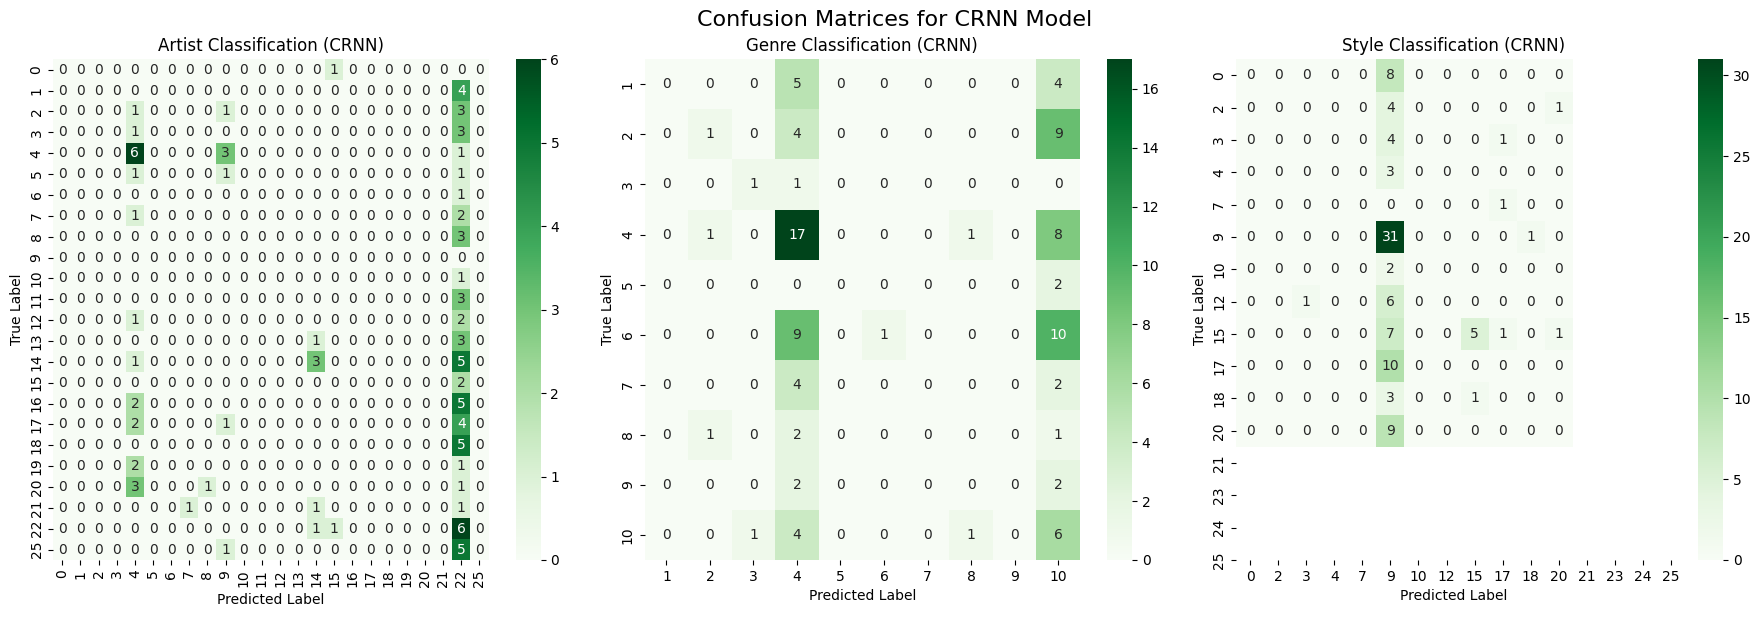

In [27]:
output_titles = ['Artist Classification (CRNN)', 'Genre Classification (CRNN)', 'Style Classification (CRNN)']

plt.figure(figsize=(18, 6))

for i in range(3):
    cm_crnn = confusion_matrix(y_true_np[i], y_pred_crnn_classes[i])

    current_class_names = all_class_names[['artist', 'genre', 'style'][i]]

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm_crnn, annot=True, fmt='d', cmap='Greens',
                xticklabels=current_class_names, yticklabels=current_class_names)
    plt.title(output_titles[i])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.suptitle('Confusion Matrices for CRNN Model', y=1.02, fontsize=16)
plt.show()

### Outlier Detection for CRNN using LSTM

Total misclassified samples for Artist (CRNN): 85


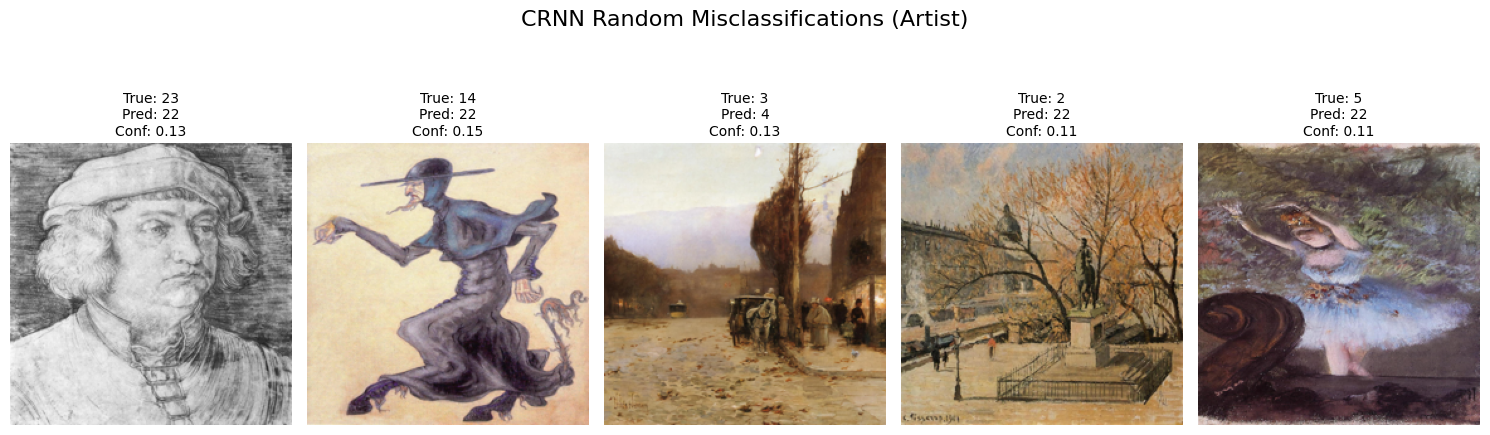

In [26]:
import numpy as np
import matplotlib.pyplot as plt

all_images = []
all_labels = []
for images_batch, labels_batch in test_data_tf:
    all_images.append(images_batch.numpy())
    all_labels.append(labels_batch[0].numpy())
all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

artist_preds_probs_crnn = crnn_model.predict(test_data_tf, verbose=0)[0]

misclassified_indices_crnn = np.where(y_true_np[0] != y_pred_crnn_classes[0])[0]

print(f"Total misclassified samples for Artist (CRNN): {len(misclassified_indices_crnn)}")

num_to_display = min(5, len(misclassified_indices_crnn))

if num_to_display > 0:
    np.random.shuffle(misclassified_indices_crnn)
    display_indices = misclassified_indices_crnn[:num_to_display]

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(display_indices):
        true_label = y_true_np[0][idx]
        predicted_label = y_pred_crnn_classes[0][idx]
        confidence = artist_preds_probs_crnn[idx, predicted_label]

        plt.subplot(1, num_to_display, i + 1)
        plt.imshow(all_images[idx])
        plt.axis('off')
        plt.title(f"True: {true_label}\nPred: {predicted_label}\nConf: {confidence:.2f}", fontsize=10)
    plt.tight_layout()
    plt.suptitle('CRNN Random Misclassifications (Artist)', y=1.05, fontsize=16)
    plt.show()
else:
    print("No misclassified samples found to display for CRNN.")

### Analysis of CRNN Model :

Metrics similar to CNN were used for performance analysis of CRNN model.

- **Overall Macro F1** : CRNN slightly has higher overall macro F1 score (0.083) vs (0.034) for CNN, this suggests that the LSTM component have certainly captured some useful context.

- **Class Distribution and Classification Report** : CRNN also suffered from severe class imbalance, with prediction biased towards dominant classes.

**Conclusion for CRNN** : While CRNN showed a significant improvement in F1 score, accuracy and loss over the CNN only architecture, the problems faced by both the models were the same :
- Small dataset
- Class imbalance

These could be solved by :
- Data augmentation
- Adding class weights to minority classes while training.

## Comparative Analysis of CNN vs. CRNN

Comparing the key performance metrics for three of the models.

| Metric                  | CNN (ResNet50) | CRNN (ResNet50 + LSTM) | CRNN (ResNet50 + GRU) |
|-------------------------|---------------:|-----------------------:|----------------------:|
| **Overall Macro F1**    | 0.034          | 0.083                  |    0.006                   |
| Artist Output Accuracy  | 0.120          | 0.170                  |   0.050                    |
| Genre Output Accuracy   | 0.230          | 0.290                  |    0.040                  |
| Style Output Accuracy   | 0.340          | 0.380                  |   0.050                    |

**Summary of Comparison:**

*   The **CRNN model with LSTM showed a modest improvement** across all metrics (accuracy and overall Macro F1) compared to the CNN. This suggests that the recurrent component, even with a small dataset, might offer a slight advantage in processing the spatial features for classification.
*   The GRU model however, performed even worse than the only CNN model, which was surprising to note here and was not expected.
*   However, **both (LSTM and CNN) models still exhibit very low performance**, especially as indicated by the Macro F1-scores. This strongly points to underlying data limitations rather than architectural shortcomings as the primary bottleneck.
*   The **class imbalance problem** was pervasive in both models, leading to biased predictions towards majority classes.

### Outlier Detection
I initially attempeted to bring out :
- Low-confidence predictions
- High-confidence misclassifications (model was incorrect but highly confident (threshold > 0.5))

Since, both the attempts did not yield useful results, I proceeded with identifying random misclasssified samples.

This allowed to understand the model's failure to generalize due to limited data.

## Overall Conclusion

This notebook successfully demonstrated the implementation and evaluation of CNN and CRNN models for multi-label image classification on a constrained dataset, effectively utilizing transfer learning with ResNet50 and explored the benefits of adding recurrent layers.

Addressed all aspects of the task:

*   **Model Architectures:** Defined and implemented both CNN and CRNN.
*   **Evaluation Metrics:** Critically selected and applied appropriate metrics (Macro F1, Classification Report, Confusion Matrices) suitable for imbalanced data, not relying on simple accuracy.
*   **Outlier Detection:** Visualized misclassified samples as a form of outliers, providing insights of the model's failures at certain images.

**Primary Problems I faced:**

1.  **Limited Dataset Size:** Due to computation constraints (using google colab) i was restricted to using small dataset (wikiart-tiny with just 1000 images) which is insufficient for training robust models, even with pretrained backbones and using transfer learning leading to poor feature extraction and generalization.

2.  **Severe Class Imbalance:** The uneven distribution of samples across artists, genres, and styles heavily biased model predictions, resulting in extremely low performance for minority classes.

**Possible solutions:**

To significantly improve model performance, overcoming the above limitations, :

*   **Data Augmentation:** Applying transformations and increasing the dataset size can help for improvement.
*   **Class Weighting:** Assigning higher weights to minority classes in the loss function can make the model to learn those classes better.
*   **More Data:** A better dataset with balanced distribution and enough size.
*   **Fine-tuning:** Lowering the learning rate of CNN gave me a little better result, so unfreezing and fine-tuning some of the top layers of resnet50 with small learning rate and help the model to learn more specific features.

This detailed analysis provides a strong starting point with possible problems and solutions that can help architect more better models and much better data handling for achieving bettter performance on such challenging multi-label classification tasks.